# Noise2Void 去噪训练

本 notebook 实现 Noise2Void 盲点网络训练：
- **无需配对数据**：单张带噪图像即可训练
- **盲点机制**：破坏随机像素，只在这些位置计算损失
- **适用于**：显微镜图像、生物医学图像

参考：Krull et al. "Noise2Void - Learning Denoising from Single Noisy Images" (CVPR 2019)

## 1. 导入依赖

In [8]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.4.0+cu121
CUDA 可用：True


## 2. 工具函数

In [9]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def percentile_norm(x, pmin=0.1, pmax=99.9, eps=1e-8):
    lo = np.percentile(x, pmin)
    hi = np.percentile(x, pmax)
    return np.clip((x - lo) / max(hi - lo, eps), 0.0, 1.0)

def load_image(path):
    arr = np.array(Image.open(path)).astype(np.float32)
    return arr.mean(axis=2) if arr.ndim == 3 else arr

def save_image(path, x):
    x = np.clip(x / max(x.max(), 1e-8), 0.0, 1.0)
    Image.fromarray((x * 65535.0).astype(np.uint16)).save(path)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def reflect_pad(x, multiple=16, margin=16):
    h, w = x.shape
    new_h = int(math.ceil(h / multiple) * multiple)
    new_w = int(math.ceil(w / multiple) * multiple)
    pad_h, pad_w = max(new_h - h, 0), max(new_w - w, 0)
    top, bottom = margin + pad_h // 2, margin + pad_h - pad_h // 2
    left, right = margin + pad_w // 2, margin + pad_w - pad_w // 2
    return np.pad(x, ((top, bottom), (left, right)), mode="reflect"), (top, bottom, left, right)

def crop_pad(x, padinfo, scale=1):
    top, bottom, left, right = [p * scale for p in padinfo]
    h, w = x.shape
    return x[top:h - bottom, left:w - right]

## 3. Noise2Void 数据集

输入形状：torch.Size([1, 128, 128])
目标形状：torch.Size([1, 128, 128])
掩码形状：torch.Size([1, 128, 128])
盲点比例：9.4%


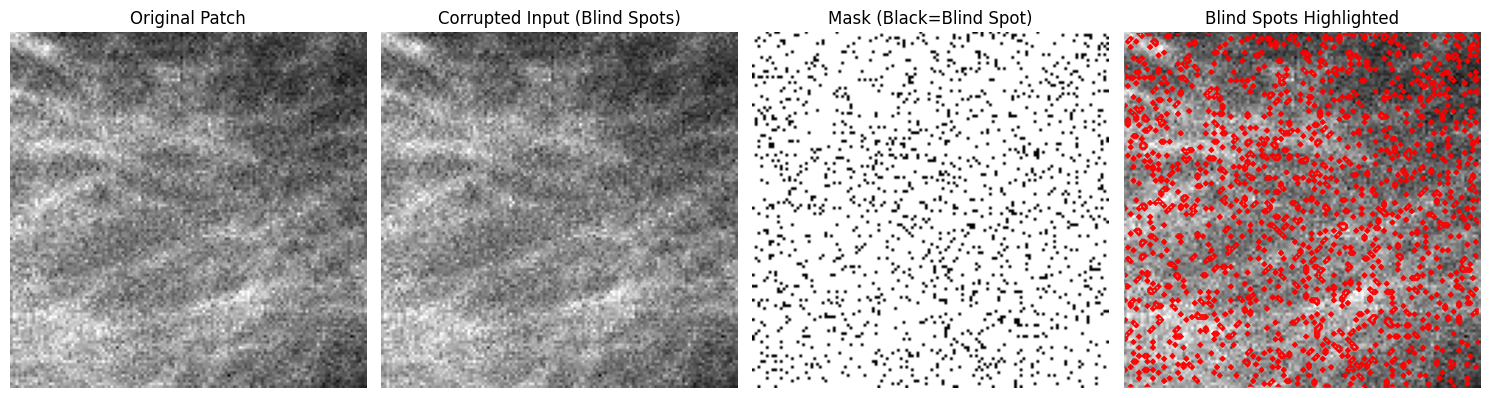

In [10]:
class Noise2VoidDataset(Dataset):
    """
    Noise2Void 数据集：生成盲点掩码和被破坏的输入
    
    参数:
        img: 输入图像 (归一化到 [0,1])
        patch_size: 训练 patch 大小
        n_samples: 每 epoch 采样数
        mask_ratio: 保留像素比例 (0.9 = 90% 保留，10% 盲点)
        window_size: 邻域窗口大小 (用于填充盲点)
    """
    def __init__(self, img, patch_size=128, n_samples=2000, 
                 mask_ratio=0.9, window_size=5):
        self.img = img
        self.patch_size = patch_size
        self.n_samples = n_samples
        self.mask_ratio = mask_ratio
        self.window_size = window_size
        self.h, self.w = img.shape
    
    def __len__(self):
        return self.n_samples
    
    def generate_blind_spot_mask(self, patch):
        """生成盲点掩码和被破坏的输入"""
        h, w = patch.shape
        mask = np.ones((h, w), dtype=np.float32)
        output = patch.copy()
        
        # 随机选择 (1-mask_ratio) 的像素作为盲点
        num_mask = int(h * w * (1 - self.mask_ratio))
        y_mask = np.random.randint(0, h, num_mask)
        x_mask = np.random.randint(0, w, num_mask)
        
        for y, x in zip(y_mask, x_mask):
            # 用邻域像素的值替换中心像素
            # 邻域范围：[y-window_size//2, y+window_size//2]
            y_offset = np.random.randint(-self.window_size//2, self.window_size//2 + 1)
            x_offset = np.random.randint(-self.window_size//2, self.window_size//2 + 1)
            
            y_neigh = np.clip(y + y_offset, 0, h - 1)
            x_neigh = np.clip(x + x_offset, 0, w - 1)
            
            # 确保不使用自身 (如果偏移为 0，重新采样)
            if y_offset == 0 and x_offset == 0:
                y_offset = np.random.choice([-1, 1])
                y_neigh = np.clip(y + y_offset, 0, h - 1)
            
            output[y, x] = patch[y_neigh, x_neigh]
            mask[y, x] = 0.0  # 标记为盲点
        
        return output, mask
    
    def __getitem__(self, idx):
        # 随机裁剪 patch
        h_start = np.random.randint(0, self.h - self.patch_size)
        w_start = np.random.randint(0, self.w - self.patch_size)
        
        patch = self.img[h_start:h_start + self.patch_size, 
                        w_start:w_start + self.patch_size]
        
        # 生成盲点掩码
        input_patch, mask = self.generate_blind_spot_mask(patch)
        
        # 添加通道维度 (1, H, W)
        return (
            torch.from_numpy(input_patch[None]),  # 被破坏的输入
            torch.from_numpy(patch[None]),        # 原始目标
            torch.from_numpy(mask[None])          # 盲点掩码
        )


# 测试数据集
img_test = percentile_norm(load_image("datasets/Microtubule/train_data/01.tif"))
dataset_test = Noise2VoidDataset(img_test, patch_size=128, n_samples=5)

input_patch, target_patch, mask = dataset_test[0]
print(f"输入形状：{input_patch.shape}")
print(f"目标形状：{target_patch.shape}")
print(f"掩码形状：{mask.shape}")
print(f"盲点比例：{(1 - mask.mean()) * 100:.1f}%")

# 可视化
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(target_patch.squeeze(), cmap="gray")
plt.title("Original Patch")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(input_patch.squeeze(), cmap="gray")
plt.title("Corrupted Input (Blind Spots)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Mask (Black=Blind Spot)")
plt.axis("off")

# 高亮显示盲点区域
plt.subplot(1, 4, 4)
plt.imshow(target_patch.squeeze(), cmap="gray")
blind_spots = np.where(mask.squeeze() == 0, 1, 0)
plt.contour(blind_spots, colors='red', linewidths=0.5)
plt.title("Blind Spots Highlighted")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/n2v_dataset_visualization.png", dpi=150)
plt.show()

## 4. 盲点 UNet 模型

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_conv=2):
        super().__init__()
        layers = []
        for i in range(n_conv):
            layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(depth):
            out_ch = base_ch * (2 ** i)
            self.blocks.append(ConvBlock(ch, out_ch, n_conv))
            self.pools.append(nn.MaxPool2d(2))
            ch = out_ch
        self.out_ch = ch

    def forward(self, x):
        skips = []
        for blk, pool in zip(self.blocks, self.pools):
            x = blk(x)
            skips.append(x)
            x = pool(x)
        return x, skips


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_conv=2):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        layers = [nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True)]
        cur = out_ch
        for _ in range(n_conv - 1):
            next_ch = max(out_ch // 2, 1)
            layers.extend([nn.Conv2d(cur, next_ch, 3, padding=1), nn.ReLU(inplace=True)])
            cur = next_ch
        self.conv = nn.Sequential(*layers)
        self.out_ch = cur

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        return self.conv(torch.cat([x, skip], dim=1))


class UNetStage(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=2):
        super().__init__()
        self.encoder = Encoder(in_ch, base_ch, depth, n_conv)
        mid_ch = self.encoder.out_ch * 2
        self.mid = nn.Sequential(
            nn.Conv2d(self.encoder.out_ch, mid_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, self.encoder.out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.decoders = nn.ModuleList()
        cur_ch = self.encoder.out_ch
        for i in reversed(range(depth)):
            skip_ch = base_ch * (2 ** i)
            block = DecoderBlock(cur_ch, skip_ch, skip_ch, n_conv)
            self.decoders.append(block)
            cur_ch = block.out_ch
        self.out_ch = cur_ch

    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.mid(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        return x


class Noise2VoidUNet(nn.Module):
    """
    Noise2Void 盲点 UNet
    
    关键：使用像素 shuffle 实现盲点卷积
    参考：Noise2Void 论文中的 blind-spot network 设计
    """
    def __init__(self, base_ch=64, depth=3, n_conv=2):
        super().__init__()
        # 稍微减小深度以避免过拟合
        self.encoder = UNetStage(1, base_ch, depth, n_conv)
        self.out = nn.Conv2d(self.encoder.out_ch, 1, 3, padding=1)

    def forward(self, x):
        feat = self.encoder(x)
        return self.out(feat)


# 测试模型
model = Noise2VoidUNet(base_ch=64, depth=3, n_conv=2).to(device)
x = torch.randn(1, 1, 128, 128).to(device)
y = model(x)
print(f"输入形状：{x.shape} -> 输出形状：{y.shape}")
print(f"模型参数量：{sum(p.numel() for p in model.parameters()):,}")

输入形状：torch.Size([1, 1, 128, 128]) -> 输出形状：torch.Size([1, 1, 128, 128])
模型参数量：5,440,641


## 5. 训练函数

In [12]:
def train_noise2void(
    image_path="datasets/Microtubule/train_data/01.tif",
    out_dir="./output_n2v",
    patch_size=128,
    n_samples=5000,
    batch_size=4,
    epochs=50,
    lr=1e-4,
    lr_step=15,
    lr_gamma=0.5,
    mask_ratio=0.9,
    window_size=5,
    base_ch=64,
    depth=3,
    n_conv=2,
    seed=42,
):
    """
    训练 Noise2Void 盲点网络
    
    参数:
        image_path: 输入图像路径
        out_dir: 输出目录
        patch_size: 训练 patch 大小
        n_samples: 每 epoch 采样数
        batch_size: 批次大小
        epochs: 训练轮数
        lr: 学习率
        mask_ratio: 保留像素比例 (0.9 = 10% 盲点)
        window_size: 邻域窗口大小
    """
    set_seed(seed)
    ensure_dir(out_dir)
    
    print(f"设备：{device}")
    print(f"加载图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    
    print("创建 Noise2Void 数据集...")
    dataset = Noise2VoidDataset(
        img, patch_size, n_samples, 
        mask_ratio=mask_ratio, window_size=window_size
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    print("初始化盲点 UNet...")
    model = Noise2VoidUNet(base_ch, depth, n_conv).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)
    criterion = nn.L1Loss()
    
    best_path = os.path.join(out_dir, "best_n2v.pt")
    best_loss = float("inf")
    history = []
    
    print("=" * 60)
    print(f"开始训练 Noise2Void，{epochs} epochs")
    print(f"盲点比例：{(1-mask_ratio)*100:.0f}%, 窗口大小：{window_size}")
    print("=" * 60)
    
    model.train()
    for epoch in range(epochs):
        losses = []
        for input_patch, target_patch, mask in loader:
            input_patch = input_patch.to(device)
            target_patch = target_patch.to(device)
            mask = mask.to(device)
            
            # 前向传播
            output = model(input_patch)
            
            # 只在盲点位置计算损失
            # mask=0 表示盲点，mask=1 表示保留
            loss = criterion(output * (1 - mask), target_patch * (1 - mask))
            
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        
        scheduler.step()
        mean_loss = np.mean(losses)
        lr_now = optimizer.param_groups[0]["lr"]
        history.append(mean_loss)
        
        print(f"epoch {epoch+1:03d}/{epochs:03d} | loss={mean_loss:.6f} lr={lr_now:.2e}")
        
        if mean_loss < best_loss:
            best_loss = mean_loss
            torch.save({
                "model": model.state_dict(),
                "cfg": {"base_ch": base_ch, "depth": depth, "n_conv": n_conv,
                       "mask_ratio": mask_ratio, "window_size": window_size}
            }, best_path)
    
    # 绘制损失曲线
    plt.figure(figsize=(8, 4))
    plt.plot(history, 'b-', linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("L1 Loss (Blind Spots Only)")
    plt.title("Noise2Void Training Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(out_dir, "loss_curve.png"), dpi=150)
    plt.show()
    
    print(f"\n训练完成！模型已保存：{best_path}")
    return best_path, history

## 6. 推理函数

In [13]:
@torch.no_grad()
def infer_noise2void(image_path, checkpoint_path, out_dir="./output_n2v"):
    """
    使用训练好的 Noise2Void 模型进行去噪
    """
    ensure_dir(out_dir)
    
    print(f"加载模型：{checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg = ckpt["cfg"]
    
    model = Noise2VoidUNet(cfg["base_ch"], cfg["depth"], cfg["n_conv"]).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    
    print(f"处理图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    img_pad, padinfo = reflect_pad(img, multiple=2 ** cfg["depth"], margin=16)
    x = torch.from_numpy(img_pad[None, None]).float().to(device)
    
    output = model(x)
    output_np = crop_pad(output.squeeze().cpu().numpy(), padinfo, scale=1)
    
    name = Path(image_path).stem
    output_path = os.path.join(out_dir, f"{name}_n2v_denoised.tif")
    save_image(output_path, percentile_norm(output_np))
    
    print(f"去噪结果：min={output_np.min():.4f}, max={output_np.max():.4f}")
    print(f"已保存：{output_path}")
    
    # 可视化
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Input (Noisy)")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(img, cmap="gray")
    plt.title("Input (Zoom)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(output_np, cmap="gray")
    plt.title("Noise2Void Denoised")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{name}_n2v_result.png"), dpi=150)
    plt.show()
    
    return output_path, output_np

## 7. 配置参数

In [28]:
# 数据路径
IMAGE_PATH = "datasets/Microtubule/train_data/01.tif"
OUT_DIR = "./output_n2v"

# 数据集配置
PATCH_SIZE = 128
N_SAMPLES = 5000       # 每 epoch 采样数 (比自监督方法多一些)
BATCH_SIZE = 16

# 盲点配置
MASK_RATIO = 0.85       # 90% 像素保留，10% 盲点
WINDOW_SIZE = 15        # 邻域窗口大小

# 训练配置
EPOCHS = 5            # 训练轮数
LR = 1e-4
LR_STEP = 15
LR_GAMMA = 0.5

# 模型配置
BASE_CH = 64
DEPTH = 3              # 比自监督方法浅一些
N_CONV = 2

SEED = 42

print("Noise2Void 配置已设置完成")
print(f"图像路径：{IMAGE_PATH}")
print(f"输出目录：{OUT_DIR}")
print(f"盲点比例：{(1-MASK_RATIO)*100:.0f}%")

Noise2Void 配置已设置完成
图像路径：datasets/Microtubule/train_data/01.tif
输出目录：./output_n2v
盲点比例：15%


## 8. 开始训练

设备：cuda
加载图像：datasets/Microtubule/train_data/01.tif
创建 Noise2Void 数据集...
初始化盲点 UNet...
开始训练 Noise2Void，5 epochs
盲点比例：15%, 窗口大小：15
epoch 001/005 | loss=0.012070 lr=1.00e-04
epoch 002/005 | loss=0.008688 lr=1.00e-04
epoch 003/005 | loss=0.008670 lr=1.00e-04
epoch 004/005 | loss=0.008652 lr=1.00e-04
epoch 005/005 | loss=0.008663 lr=1.00e-04


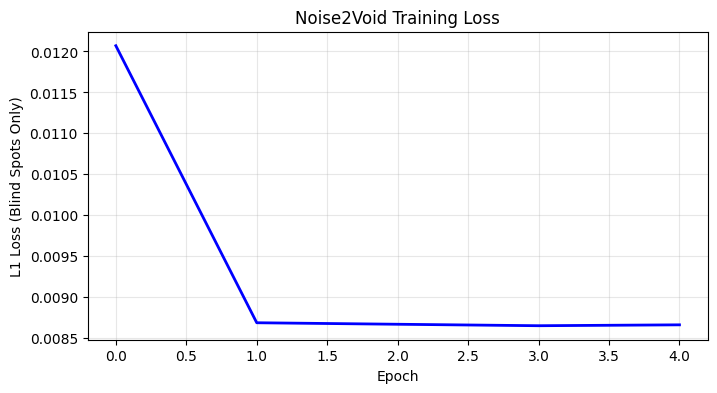


训练完成！模型已保存：./output_n2v/best_n2v.pt


In [29]:
# 训练 Noise2Void 模型
checkpoint_path, history = train_noise2void(
    image_path=IMAGE_PATH,
    out_dir=OUT_DIR,
    patch_size=PATCH_SIZE,
    n_samples=N_SAMPLES,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    lr_step=LR_STEP,
    lr_gamma=LR_GAMMA,
    mask_ratio=MASK_RATIO,
    window_size=WINDOW_SIZE,
    base_ch=BASE_CH,
    depth=DEPTH,
    n_conv=N_CONV,
    seed=SEED,
)

## 9. 测试推理

加载模型：./output_n2v/best_n2v.pt
处理图像：datasets/Microtubule/train_data/01.tif
去噪结果：min=0.0729, max=1.0235
已保存：./output_n2v/01_n2v_denoised.tif


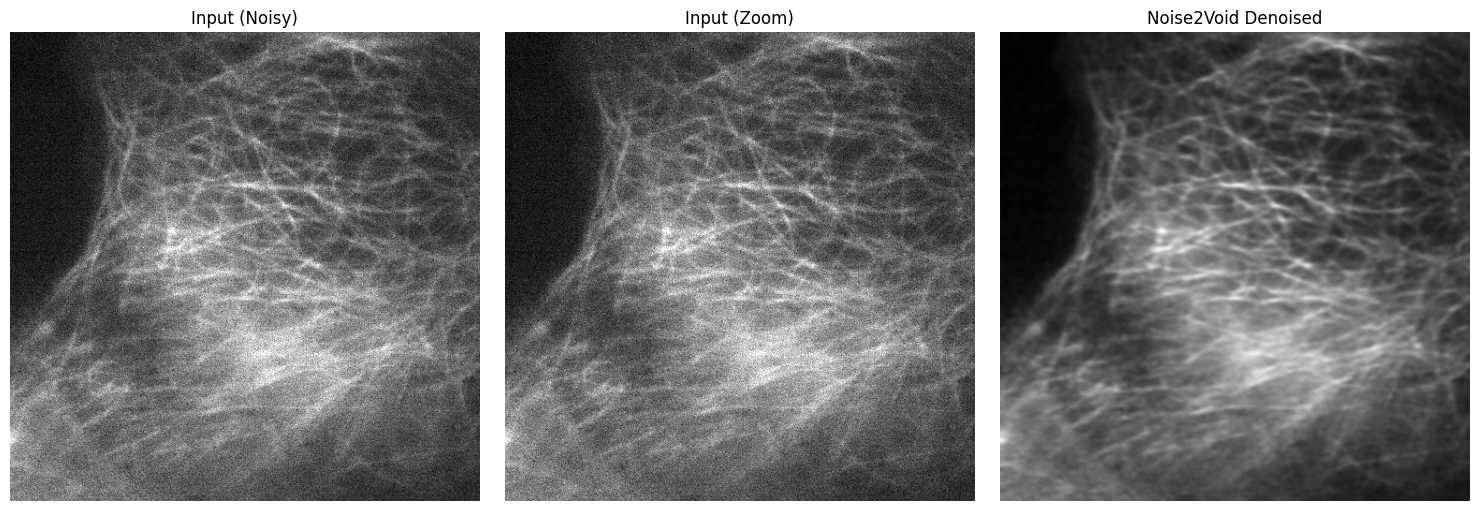

In [30]:
# 使用训练好的模型进行推理
output_path, output_np = infer_noise2void(
    image_path=IMAGE_PATH,
    checkpoint_path=checkpoint_path,
    out_dir=OUT_DIR,
)

## 10. 结果对比

In [ ]:
# 加载并对比结果
original = load_image(IMAGE_PATH)
original_norm = percentile_norm(original)
n2v_result = load_image(output_path)
n2v_result_norm = percentile_norm(n2v_result)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_norm, cmap="gray")
plt.title(f"Original ({original.shape[0]}x{original.shape[1]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(n2v_result_norm, cmap="gray")
plt.title(f"Noise2Void Denoised ({n2v_result.shape[0]}x{n2v_result.shape[1]})")
plt.axis("off")

# 剖面线对比
center_y = original.shape[0] // 2
x = np.arange(original.shape[1])
plt.subplot(1, 3, 3)
plt.plot(x, original_norm[center_y, :], 'b-', label='Original', alpha=0.7)
plt.plot(x, n2v_result_norm[center_y, :], 'r-', label='N2V Denoised', alpha=0.7)
plt.xlabel("Pixel")
plt.ylabel("Normalized Intensity")
plt.title(f"Horizontal Profile (y={center_y})")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "final_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\n所有结果已保存到：{OUT_DIR}")
print(f"- 去噪图像：{output_path}")
print(f"- 损失曲线：{os.path.join(OUT_DIR, 'loss_curve.png')}")
print(f"- 对比图：{os.path.join(OUT_DIR, 'final_comparison.png')}")